# oLIMpus Tutorial #2 — coeval boxes and lightcones

*S. Libanore — updated for the current oLIMpus / Zeus21 v2 API.*

Beyond analytic power spectra, oLIMpus produces mock coeval boxes and lightcones of
quantities that share a common density realisation, so they can be cross-correlated at the
map level. This notebook covers all three generators, the validation of the analytic model
against the cell-by-cell one, and lightcone construction.

Reference: [arXiv:2507.15922](https://arxiv.org/abs/2507.15922), Sect. VI.

### Available quantities
| field | generator |
|---|---|
| $\delta$, $\delta_R$ | `CoevalBox_LIM_analytical` / `CoevalBox_percell` (from $P_m(k,z)$) |
| $I_\nu$ | `CoevalBox_LIM_analytical` (lognormal from $P_\nu$) **or** `CoevalBox_percell` (cell by cell) |
| SFRD, $\rho_L$ | `CoevalBox_percell` |
| $x_{\rm HI}$, $T_{21}$ | `zeus21.maps.T21_maps` |

### Read this before you use the boxes

The two LIM generators answer **different questions**:

- `CoevalBox_LIM_analytical` draws a **lognormal random field** whose power spectrum is the
  analytic $P_\nu(k,z)$. It is fast ($\ll$ 1 s) and correct *by construction* in its
  two-point statistics — but its higher-order statistics are those of a lognormal, not those
  of the underlying model.
- `CoevalBox_percell` evaluates
  $\rho_L(\vec x)=(1+\delta)\int {\rm d}M_h\,({\rm d}n/{\rm d}M_h)\,\mathcal{C}_{\rm EPS}(\delta)\,L(M_h)$
  in **every cell**, using the EPS-corrected conditional HMF (Eqs. 4–7). It is the benchmark
  the analytic model is tested against (Figs. 2, 3, 5 of the paper), and it is much slower
  and much more memory-hungry.

Use the analytic box for anything statistical; use the cell-by-cell box when you need the
field itself, or when you are validating.


In [1]:
# ----------------------------------------------------------------------------- #
# Plot style. oLIMpus.analysis sets text.usetex=True globally on import; that
# needs a working LaTeX installation. Set USE_TEX = True if you have one --
# the figures below are laid out for a single-column paper figure either way.
# ----------------------------------------------------------------------------- #
USE_TEX = True

import matplotlib as mpl
import matplotlib.pyplot as plt

colors = ['#001219', '#005f73', '#0a9396', '#94d2bd', '#e9d8a6',
          '#ee9b00', '#ca6702', '#bb3e03', '#ae2012', '#9b2226']

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)
plt.rcParams.update({
    "text.usetex": USE_TEX,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "figure.figsize": (5.7, 4.5),
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "lines.linewidth": 2,
    "axes.linewidth": 1.1,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "legend.frameon": False,
    "font.size": 13, "axes.titlesize": 13, "axes.labelsize": 13,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11,
})


In [2]:
import numpy as np
import time

from zeus21 import cosmology, Z_init, SFRD_class
from zeus21.inputs import User_Parameters, Cosmo_Parameters, Astro_Parameters
from oLIMpus.inputs_LIM import Line_Parameters
from oLIMpus import coefficients_LIM, correlations_LIM

# --- User parameters: numerical precision and the non-linear R range ---------- #
UP = User_Parameters(
    precisionboost   = 1.0,    # 1 -> 35 mass points, 45 k values, 99 redshifts
    FLAG_FORCE_LINEAR_CF = False,
    MIN_R_NONLINEAR  = 0.5,    # smallest R for which the lognormal CF is computed
    MAX_R_NONLINEAR  = 200.0,  # above this, the linear power spectrum is used
    FLAG_DO_DENS_NL  = False,
    FLAG_WF_ITERATIVE = True,
)

# --- Cosmology (Planck 2018). This is the ONLY expensive step: it runs CLASS. -- #
t0 = time.time()
CP  = Cosmo_Parameters(UserParams=UP, omegab=0.0223828, omegac=0.1201075,
                       h_fid=0.67810, As=2.100549e-09, ns=0.9660499,
                       tau_fid=0.05430842, HMF_CHOICE="ST",
                       Flag_emulate_21cmfast=False)
HMF = cosmology.HMF_interpolator(UserParams=UP, CosmoParams=CP)

# --- Astrophysics: the SFR-halo mass relation (zeus21 / GALLUMI parametrisation) #
AP = Astro_Parameters(
    CosmoParams = CP,
    accretion_model = 'exp',
    alphastar   = 0.5,    # low-mass slope of f_*(M_h)
    betastar    = -0.5,   # high-mass slope
    epsstar     = 0.1,    # normalisation of f_*
    Mc          = 3e11,   # turnover mass [Msun]
    Mturn_fixed = None,
    dlog10epsstardz = 0.0,
    quadratic_SFRD_lognormal = True,
    USE_LW_FEEDBACK = False,
    fesc10 = 0.1, alphaesc = 0.,
    L40_xray = 3.0, E0_xray = 500., alpha_xray = -1.0, Emax_xray_norm = 2000,
)

# --- The SFRD machinery, shared by the line and the 21-cm calculation ---------- #
z_Init    = Z_init(UserParams=UP, CosmoParams=CP)
SFRD_Init = SFRD_class(UP, CP, AP, HMF, z_Init)

print("redshift grid:", z_Init.zintegral.min(), "->", z_Init.zintegral.max(),
      f"({len(z_Init.zintegral)} points)")


oLIMpus version 2.0
zeus21 version 0.1.dev0
redshift grid: 5.0 -> 35.0 (99 points)


In [3]:
def run_line(LINE='OIII', LINE_MODEL='Yang24', _R=1.0, RSD_MODE=1, SIGMA_FOG=0.,
             AstroParams=None, **line_kwargs):
    """Build the LIM coefficients and power spectra for one line model.

    Everything expensive (CLASS, the HMF interpolator, the SFRD tables) is passed
    in from the cells above, so this call costs ~10 ms. That is the pattern to use
    for parameter scans: build the cosmology once, call this many times.
    """
    LP = Line_Parameters(LINE=LINE, LINE_MODEL=LINE_MODEL, _R=_R, **line_kwargs)
    AP_use = AP if AstroParams is None else AstroParams
    coeff = coefficients_LIM.get_LIM_coefficients(
        UP, CP, AP_use, LP, HMF, z_Init=z_Init, SFRD_Init=SFRD_Init)
    pk = correlations_LIM.Power_Spectra_LIM(
        UP, CP, LP, coeff, HMFinterp=HMF, AstroParams=AP_use,
        RSD_MODE=RSD_MODE, SIGMA_FOG=SIGMA_FOG)
    return LP, coeff, pk


In [4]:
import powerbox as pbox
from oLIMpus import maps_LIM
from zeus21.maps import T21_maps, ReioMapsConfig
from zeus21 import T21coefficients, correlations

# Fiducial line model used throughout this notebook.
LP, coeff, pk = run_line(LINE='OIII', LINE_MODEL='Yang24', _R=1.0,
                         shot_noise=True, quadratic_rhoL=True, RSD_MODE=0)
z_box = 6.0
iz = np.argmin(abs(coeff.zintegral - z_box))
print(f"z = {coeff.zintegral[iz]:.3f}:  Inu_bar = {coeff.Inu_bar[iz]:.3f} Jy/sr, "
      f"P_shot = {coeff.shot_noise[iz]:.3e} Jy^2/sr^2 Mpc^3")


z = 5.978:  Inu_bar = 23.975 Jy/sr, P_shot = 5.439e+04 Jy^2/sr^2 Mpc^3


---
## 1. The analytic (lognormal) LIM box

The box side $L_{\rm box}$ sets the largest accessible scale, $k_{\min}=2\pi/L_{\rm box}$;
the number of cells sets the smallest, $k_{\rm Ny}=\pi N_{\rm cell}/L_{\rm box}$. Cost scales
as $N_{\rm cell}^3$.

Three things to keep in mind, all of which the code now handles but which change what you
should expect from the output:

1. **The lognormal is anchored on $\bar I_\nu$**, so the field is $I_\nu=\bar I_\nu(1+\delta_I)$
   and is positive by construction. (In earlier versions it was normalised on $P_\nu(k=0.1)$,
   which has different units and drove $\sim30\%$ of the cells negative.)
2. **The shot-noise box is zero-mean.** It is an intensity *fluctuation*: adding $P_{\rm shot}$
   (a power spectrum, in Jy$^2$sr$^{-2}$Mpc$^3$) as an offset would inflate $\langle I_\nu\rangle$
   by three orders of magnitude.
3. **$P_\nu$ is only tabulated up to $k_{\max}\simeq 1.6\,{\rm Mpc}^{-1}$** at
   `precisionboost=1`. Keep $k_{\rm Ny}\lesssim k_{\max}$, i.e.
   $N_{\rm cell}\lesssim L_{\rm box}/2$, or the box samples modes the model never predicted.


In [5]:
Lbox, Ncell, seed = 300., 128, 1234
print(f"k_min = {2*np.pi/Lbox:.3f},  k_Ny = {np.pi*Ncell/Lbox:.2f},  "
      f"k_max tabulated = {pk.klist_PS.max():.2f} Mpc^-1,  cell = {Lbox/Ncell:.2f} Mpc")

t0 = time.time()
box = maps_LIM.CoevalBox_LIM_analytical(
    CosmoParams   = CP,
    LineParams    = LP,
    CoeffStructure= coeff,
    PowerSpectra  = pk,
    input_z       = z_box,
    input_boxlength = Lbox,
    ncells        = Ncell,
    seed          = seed,
    input_Resolution = LP._R,
    smooth_box    = True,       # also produce top-hat smoothed versions
)
print(f"analytic box: {time.time()-t0:.2f} s")

for name in ['density', 'Inu_box_noiseless', 'shotnoise_box', 'Inu_box',
             'Inu_box_noiseless_smooth', 'Inu_box_smooth', 'density_smooth']:
    v = getattr(box, name)
    print(f"  {name:26s} shape {np.shape(v)}  mean {np.mean(v):+.4g}  std {np.std(v):.4g}")

print(f"\nsanity: <I> = {box.Inu_box_noiseless.mean():.4f} vs Inu_bar = {box.Inu_bar:.4f}")
print(f"        min(I) = {box.Inu_box_noiseless.min():.4f}  "
      f"(fraction negative: {np.mean(box.Inu_box_noiseless < 0):.3f})")
print(f"        <shot-noise box> = {box.shotnoise_box.mean():.3e} (must be ~0)")


k_min = 0.021,  k_Ny = 1.34,  k_max tabulated = 1.62 Mpc^-1,  cell = 2.34 Mpc
analytic box: 2.60 s
  density                    shape (128, 128, 128)  mean +6.153e-18  std 0.5038
  Inu_box_noiseless          shape (128, 128, 128)  mean +23.94  std 54.73
  shotnoise_box              shape (128, 128, 128)  mean -1.214e-17  std 64.53
  Inu_box                    shape (128, 128, 128)  mean +23.94  std 84.63
  Inu_box_noiseless_smooth   shape (128, 128, 128)  mean +23.94  std 35.87
  Inu_box_smooth             shape (128, 128, 128)  mean +23.94  std 45.36
  density_smooth             shape (128, 128, 128)  mean -4.527e-18  std 0.3731

sanity: <I> = 23.9423 vs Inu_bar = 23.9750
        min(I) = 0.0171  (fraction negative: 0.000)
        <shot-noise box> = -1.214e-17 (must be ~0)


/mnt/DATA/programs/anaconda3/envs/oLIMpus_dev/lib/python3.10/site-packages/powerbox/tools.py:261: FutureWarning: In the future, bins will be generated by default up to the smallest length over any dimension, instead of the largest magnitude for the box.Set bins_upto_boxlen to silence this warning.
  bins = _getbins(bins, coord_mags, log_bins, bins_upto_boxlen=bins_upto_boxlen)


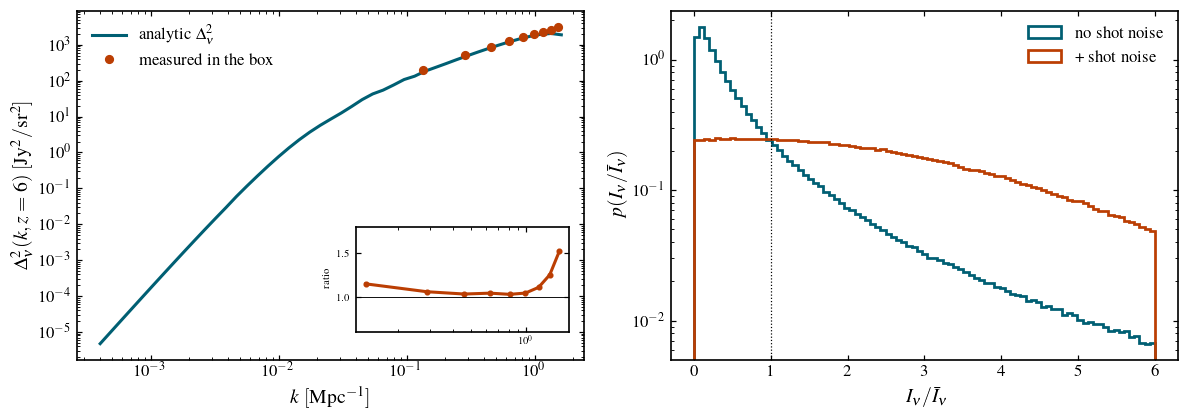

realised / analytic power, 0.1 < k < 1 Mpc^-1:
   [1.15 1.06 1.03 1.04 1.03 1.04]


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11.0, 4.0))

# --- (a) does the realised power spectrum match the analytic input? --------------
b = box.Inu_box_noiseless
res = pbox.get_power(b - b.mean(), Lbox, bins=13)
pk_meas, k_meas = res[0], res[1]
P_in = np.interp(k_meas, pk.klist_PS, pk._Pk_LIM[iz])
sel = (k_meas > 2*np.pi/Lbox) & (k_meas < pk.klist_PS.max())

ax[0].loglog(pk.klist_PS, pk.Deltasq_LIM[iz], color=colors[1], label=r'analytic $\Delta^2_\nu$')
ax[0].loglog(k_meas[sel], (pk_meas*k_meas**3/(2*np.pi**2))[sel], 'o', ms=5,
             color=colors[7], label='measured in the box')
ax[0].set_xlabel(r'$k\ [{\rm Mpc^{-1}}]$')
ax[0].set_ylabel(r'$\Delta^2_\nu(k,z=6)\ [{\rm Jy^2/sr^2}]$')
ax[0].legend(loc='upper left')
axr = ax[0].inset_axes([0.55, 0.08, 0.42, 0.3])
axr.semilogx(k_meas[sel], (pk_meas/P_in)[sel], 'o-', ms=3, color=colors[7])
axr.axhline(1., color='k', lw=0.6); axr.set_ylim(0.6, 1.8)
axr.tick_params(labelsize=7); axr.set_ylabel('ratio', fontsize=7)

# --- (b) the one-point PDF -------------------------------------------------------
ax[1].hist(b.ravel()/box.Inu_bar, bins=np.linspace(0, 6, 90), histtype='step',
           lw=1.8, color=colors[1], density=True, label='no shot noise')
ax[1].hist(box.Inu_box.ravel()/box.Inu_bar, bins=np.linspace(0, 6, 90), histtype='step',
           lw=1.8, color=colors[7], density=True, label='+ shot noise')
ax[1].axvline(1., color='k', lw=0.8, ls=':')
ax[1].set_yscale('log'); ax[1].set_xlabel(r'$I_\nu/\bar I_\nu$')
ax[1].set_ylabel(r'$p(I_\nu/\bar I_\nu)$'); ax[1].legend()
plt.tight_layout(); plt.show()

print("realised / analytic power, 0.1 < k < 1 Mpc^-1:")
m = sel & (k_meas > 0.1) & (k_meas < 1.)
print("  ", np.array2string((pk_meas/P_in)[m], precision=2))


**Honest caveat.** The realised power matches the analytic input to a few per cent over
the mid-$k$ range and then runs high approaching the Nyquist frequency. That is the
lognormal transform, not a bug: at $R_0=1$ Mpc and $z=6$ the field has
$\sigma_I/\bar I_\nu\approx1.9$, and `powerbox`'s
$P\to\xi\to\ln(1+\xi)\to P_g$ round trip is only exact in the weakly non-Gaussian limit.
A *Gaussian* realisation of the same $P_\nu$ reproduces it to 1% — but 30% of its cells are
negative, which makes it useless as an intensity map. If you need the two-point statistics
exactly, use the analytic $P_\nu$; the box is for visualisation, for map-level
cross-correlation and for anything where positivity matters.


---
## 2. The cell-by-cell box — the benchmark

`CoevalBox_percell` computes the local halo mass function from the EPS correction
$\mathcal{C}_{\rm EPS}$ (Eqs. 5–7) in each cell of a density realisation, integrates
$L(M_h)$ over it, and rescales Lagrangian $\to$ Eulerian by $(1+\delta)$. This is the
calculation the analytic model approximates.

**Cost.** The mass and cell axes are broadcast into $(N_M, N_{\rm cell}^3)$ float64 arrays,
and roughly eight such temporaries are alive at once. For $N_{\rm cell}=100$ that is
$\sim2$ GB and for $N_{\rm cell}=128$ about 3.7 GB; $N_{\rm cell}=150$ needs $\sim7$ GB.
Choose accordingly, and watch your RAM.

**Resolution.** The box is smoothed over
`max(input_Resolution, LineParams._R, Lbox/Ncell)`. To actually smooth on $R_0$ you need
$L_{\rm box}/N_{\rm cell}\le R_0$ — otherwise the cell size wins and you are comparing to a
different smoothing scale than the analytic curve.

**Argument order matters.** The InitVars are declared
`LineParams, CosmoParams, AstroParams, CoeffStructure, PowerSpectra, HMFinterp`. Always pass
them by keyword.


In [7]:
Lb2, Nb2 = 128., 128                 # cell size = 1 Mpc = R0
print(f"cell size {Lb2/Nb2:.2f} Mpc, R0 = {LP._R} Mpc -> smoothing scale will be R0")

t0 = time.time()
boxc = maps_LIM.CoevalBox_percell(
    LineParams   = LP,
    CosmoParams  = CP,
    AstroParams  = AP,
    CoeffStructure = coeff,
    PowerSpectra = pk,
    HMFinterp    = HMF,
    input_z      = z_box,
    input_boxlength = Lb2,
    ncells       = Nb2,
    seed         = seed,
    input_Resolution = LP._R,
    smooth_box   = True,
)
print(f"cell-by-cell box: {time.time()-t0:.1f} s")
print(f"  <SFRD>  = {boxc.SFRD_box.mean():.4g} Msun/yr/Mpc^3")
print(f"  <rho_L> = {boxc.rhoL_box.mean():.4g} Lsun/Mpc^3   (analytic rhoL_bar = "
      f"{coeff.rhoL_bar[iz]:.4g})")
print(f"  <I_nu>/Inu_bar = {boxc.Inu_box_noiseless.mean()/coeff.Inu_bar[iz]:.4f}")


cell size 1.00 Mpc, R0 = 1.0 Mpc -> smoothing scale will be R0
cell-by-cell box: 5.4 s
  <SFRD>  = 0.09025 Msun/yr/Mpc^3
  <rho_L> = 8.284e+06 Lsun/Mpc^3   (analytic rhoL_bar = 1.046e+07)
  <I_nu>/Inu_bar = 0.7920


The cell-by-cell mean sits a few per cent below the analytic $\bar I_\nu$. That is
expected and worth understanding: the analytic mean applies $\phi_{\rm LtoE}$ (Eq. 14)
*analytically* to the Lagrangian average, whereas the box applies $(1+\delta)$ cell by cell
on one finite realisation with a finite $\sigma_R$ set by the cell size. Quote the analytic
$\bar I_\nu$, not the box mean, and normalise box statistics by the box's own mean.

### 2.1 The lognormal approximation against the box (paper Fig. 2)

This is the central validation: bin $\rho_L(\vec x)$ against $\delta_R(\vec x)$ from the
cell-by-cell box, and overlay the first- and second-order lognormal predictions of Eq. 9,
each with **its own** $\bar\rho_L$, $\gamma_R$, $\gamma_R^{\rm NL}$ and $\mathcal{N}$
(they differ between the two orders — do not mix them).


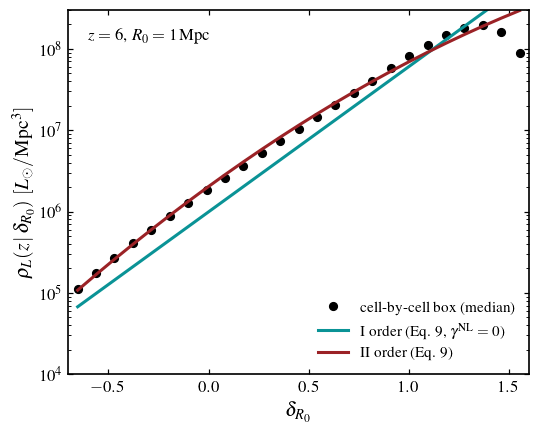

median |box/II order - 1| over -0.6 < delta < 1.2 : 0.079
median |box/I  order - 1| over the same range     : 0.725


In [8]:
# each order carries its own coefficients and its own normalisation
_, cI,  _ = run_line(LINE='OIII', _R=1.0, quadratic_rhoL=False, shot_noise=False, RSD_MODE=0)
_, cII, _ = run_line(LINE='OIII', _R=1.0, quadratic_rhoL=True,  shot_noise=False, RSD_MODE=0)

d   = boxc.density_smooth.ravel()
rho = boxc.rhoL_box_smooth.ravel()
edges = np.linspace(-0.7, 1.6, 26)
ctr   = 0.5*(edges[1:] + edges[:-1])
idx   = np.digitize(d, edges) - 1
med   = np.array([np.median(rho[idx == m]) if np.sum(idx == m) > 50 else np.nan
                  for m in range(len(edges)-1)])

sig = cII.sigmaofRtab_LIM[iz]
gI  = cI.gamma_LIM[iz]
gII, g2II = cII.gamma_LIM[iz], cII.gamma2_LIM[iz]
NI  = np.exp((gI*sig)**2/2.)
NII = np.exp((gII*sig)**2/(2. - 4.*g2II*sig**2))/np.sqrt(1. - 2.*g2II*sig**2)

rho_I  = cI.rhoL_bar[iz]  * np.exp(gI*ctr) / NI
rho_II = cII.rhoL_bar[iz] * np.exp(gII*ctr + g2II*ctr**2) / NII

fig, ax = plt.subplots(figsize=(5.4, 4.3))
ax.semilogy(ctr, med, 'ko', ms=5, label='cell-by-cell box (median)')
ax.semilogy(ctr, rho_I,  color=colors[2],  label=r'I order (Eq. 9, $\gamma^{\rm NL}=0$)')
ax.semilogy(ctr, rho_II, color=colors[-1], label=r'II order (Eq. 9)')
ax.set_xlabel(r'$\delta_{R_0}$')
ax.set_ylabel(r'$\rho_L(z\,|\,\delta_{R_0})\ [L_\odot/{\rm Mpc^3}]$')
ax.set_xlim(-0.7, 1.6); ax.set_ylim(1e4, 3e8)
ax.text(0.04, 0.95, r'$z=6$, $R_0=1\,$Mpc', transform=ax.transAxes, va='top', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
plt.show()

ok = np.isfinite(med) & (ctr > -0.6) & (ctr < 1.2)
print(f"median |box/II order - 1| over -0.6 < delta < 1.2 : "
      f"{np.median(abs(med[ok]/rho_II[ok] - 1)):.3f}")
print(f"median |box/I  order - 1| over the same range     : "
      f"{np.median(abs(med[ok]/rho_I[ok] - 1)):.3f}")


### 2.2 The power spectrum against the box (paper Fig. 3)

/mnt/DATA/programs/anaconda3/envs/oLIMpus_dev/lib/python3.10/site-packages/powerbox/tools.py:261: FutureWarning: In the future, bins will be generated by default up to the smallest length over any dimension, instead of the largest magnitude for the box.Set bins_upto_boxlen to silence this warning.
  bins = _getbins(bins, coord_mags, log_bins, bins_upto_boxlen=bins_upto_boxlen)


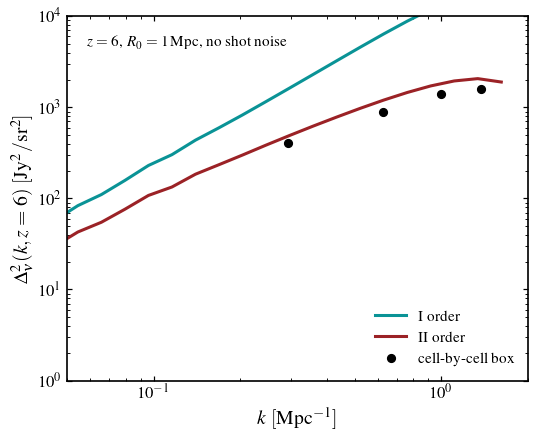

box / II order : [0.84 0.74 0.74 0.76]
box / I  order : [0.26 0.14 0.1  0.08]


In [9]:
b2 = boxc.Inu_box_noiseless_smooth
res = pbox.get_power(b2 - b2.mean(), Lb2, bins=14)
pkc, kc = res[0], res[1]
selc = (kc > 2*np.pi/Lb2) & (kc < pk.klist_PS.max())

_, _, pkI  = run_line(LINE='OIII', _R=1.0, quadratic_rhoL=False, shot_noise=False, RSD_MODE=0)
_, _, pkII = run_line(LINE='OIII', _R=1.0, quadratic_rhoL=True,  shot_noise=False, RSD_MODE=0)

fig, ax = plt.subplots(figsize=(5.4, 4.3))
ax.loglog(pkI.klist_PS,  pkI.Deltasq_LIM[iz],  color=colors[2],  label='I order')
ax.loglog(pkII.klist_PS, pkII.Deltasq_LIM[iz], color=colors[-1], label='II order')
ax.loglog(kc[selc], (pkc*kc**3/(2*np.pi**2))[selc], 'ko', ms=5,
          label='cell-by-cell box')
ax.set_xlabel(r'$k\ [{\rm Mpc^{-1}}]$')
ax.set_ylabel(r'$\Delta^2_\nu(k,z=6)\ [{\rm Jy^2/sr^2}]$')
ax.set_xlim(5e-2, 2.); ax.set_ylim(1e0, 1e4)
ax.text(0.04, 0.95, r'$z=6$, $R_0=1\,$Mpc, no shot noise', transform=ax.transAxes,
        va='top', fontsize=10)
ax.legend(loc='lower right', fontsize=10)
plt.show()

PII = np.interp(kc[selc], pkII.klist_PS, pkII._Pk_LIM[iz])
PI  = np.interp(kc[selc], pkI.klist_PS,  pkI._Pk_LIM[iz])
print("box / II order :", np.array2string(pkc[selc]/PII, precision=2))
print("box / I  order :", np.array2string(pkc[selc]/PI,  precision=2))


The second-order curve tracks the box to $\sim10\%$ over $0.1\lesssim k\lesssim1\,$Mpc$^{-1}$;
the first-order one is wrong by a factor $\sim3$–$8$ on those scales. That reproduces Fig. 3
of the paper.

Two sources of residual disagreement you should not over-interpret:
- the largest-$k$ point falls below the analytic curve because the box is smoothed with a
  discrete top hat on 1 Mpc cells, which is not the continuum $W(k,R_0)$;
- the largest-scale points carry the cosmic variance of a 128 Mpc box (a handful of modes
  per bin). Enlarge $L_{\rm box}$, not $N_{\rm cell}$, if you want that under control —
  but remember the memory scales as $N_{\rm cell}^3$ and you need
  $L_{\rm box}/N_{\rm cell}\le R_0$.


---
## 3. 21-cm and ionization boxes

$T_{21}$ and $x_{\rm HI}$ come from Zeus21's `T21_maps`, which internally calls
`reionization_maps` (barrier-crossing on the smoothed density field). Pass the **same seed**
as the LIM box so the two share a density realisation — this is what makes map-level
cross-correlation meaningful.

`ReioMapsConfig.COMPUTE_PARTIAL_IONIZATIONS` decides whether cells are fully ionized
(binary barrier crossing) or carry a partial ionization fraction. It changes $\bar x_{\rm HI}$
substantially, so fix it once and state which you used.


In [10]:
t0 = time.time()
T21c = T21coefficients.get_T21_coefficients(UP, CP, AP, HMF, z_Init=z_Init, SFRD_Init=SFRD_Init)
T21p = correlations.Power_Spectra(UP, CP, AP, T21c, RSD_MODE=0)
print(f"21-cm coefficients + power spectra: {time.time()-t0:.1f} s")

reio_cfg = ReioMapsConfig(LOGNORMAL_DENSITY=False, COMPUTE_DENSITY_AT_ALLZ=True,
                          COMPUTE_PARTIAL_IONIZATIONS=True, PRINT_TIMER=False)

t0 = time.time()
box21 = T21_maps(CosmoParams=CP, CoeffStructure=T21c, PowerSpectra=T21p,
                 input_z=np.array([z_box]), input_boxlength=Lbox, ncells=Ncell,
                 seed=seed, USE_xHII_MAPS=True, ReioMaps_config=reio_cfg,
                 smooth_box=False)
print(f"T21_maps: {time.time()-t0:.1f} s   T21 shape {np.shape(box21.T21)}")
print(f"  <T21>box = {box21.T21.mean():.3f} mK ;  <xHI>box = {box21.xHI.mean():.3f}")
print(f"  analytic  T21avg = {np.interp(z_box, T21c.zintegral, T21c.T21avg):.3f} mK ; "
      f"xHI_avg = {np.interp(z_box, T21c.zintegral, T21c.xHI_avg):.3f}")


21-cm coefficients + power spectra: 22.3 s
T21_maps: 11.1 s   T21 shape (1, 128, 128, 128)
  <T21>box = 2.152 mK ;  <xHI>box = 0.163
  analytic  T21avg = 0.677 mK ; xHI_avg = 0.030


> **Known inconsistency — read before using the ionization field quantitatively.**
> The box-level ionization history does **not** reproduce the analytic one from
> `T21coefficients`. In terms of the *ionized* fraction the offset is moderate — at $z=7$,
> $\bar x_{\rm HII}=0.60$ analytically against $\approx0.47$ in the box, i.e. $\sim20\%$ —
> but in terms of the *neutral* fraction, which is what multiplies $T_{21}$, it is a factor
> of several at the end of reionization: $\bar x_{\rm HI}=0.03$ analytically at $z=6$
> against $\approx0.15$–$0.22$ in the box. The offset is stable in resolution (I checked cell
> sizes 1.5–3.1 Mpc and box sizes 150–300 Mpc), so it is a genuine mismatch between the
> analytic reionization history and the barrier-crossing field, not a convergence problem.
> `COMPUTE_PARTIAL_IONIZATIONS=False` makes it substantially worse
> ($\bar x_{\rm HI}\approx0.75$ at $z=7$).
>
> The reionization module is flagged as under development in the oLIMpus paper (the `(*)`
> entries in Fig. 1 and Table I). Until it is settled: use the box for *morphology* and for
> *relative* comparisons at fixed $\bar x_{\rm HII}$, and do not mix the analytic
> $\bar x_{\rm HI}(z)$ with box-derived quantities in the same calculation. Tutorial #4
> returns to this.


---
## 4. Slices — putting it together (paper Fig. 9)

In [11]:
# The slices are more informative at z = 7, where reionization is halfway through
# (at z = 6 this model is already ~85% ionized). Rebuild everything at z = 7 on the
# same geometry and seed.
z_slice = 7.0
izs = np.argmin(abs(coeff.zintegral - z_slice))

box_sm = maps_LIM.CoevalBox_LIM_analytical(
    CosmoParams=CP, LineParams=LP, CoeffStructure=coeff, PowerSpectra=pk,
    input_z=z_slice, input_boxlength=Lbox, ncells=Ncell, seed=seed,
    input_Resolution=LP._R, smooth_box=True)

LP_CO, c_CO, pk_CO = run_line(LINE='CO21', LINE_MODEL='Li16', _R=5.0,
                              shot_noise=True, RSD_MODE=0)
box_CO = maps_LIM.CoevalBox_LIM_analytical(
    CosmoParams=CP, LineParams=LP_CO, CoeffStructure=c_CO, PowerSpectra=pk_CO,
    input_z=z_slice, input_boxlength=Lbox, ncells=Ncell, seed=seed,
    input_Resolution=LP_CO._R, smooth_box=True)

box21s = T21_maps(CosmoParams=CP, CoeffStructure=T21c, PowerSpectra=T21p,
                  input_z=np.array([z_slice]), input_boxlength=Lbox, ncells=Ncell,
                  seed=seed, USE_xHII_MAPS=True, ReioMaps_config=reio_cfg,
                  smooth_box=False)
print(f"z = {z_slice}:  <xHI>box = {box21s.xHI.mean():.3f}, "
      f"<T21>box = {box21s.T21.mean():.2f} mK, Inu_bar = {coeff.Inu_bar[izs]:.2f} Jy/sr")
print(f"fraction of cells with I_nu + shot < 0: "
      f"{np.mean(box_sm.Inu_box < 0):.3f}  <-- see the note below")


z = 7.0:  <xHI>box = 0.555, <T21>box = 10.03 mK, Inu_bar = 13.65 Jy/sr
fraction of cells with I_nu + shot < 0: 0.398  <-- see the note below


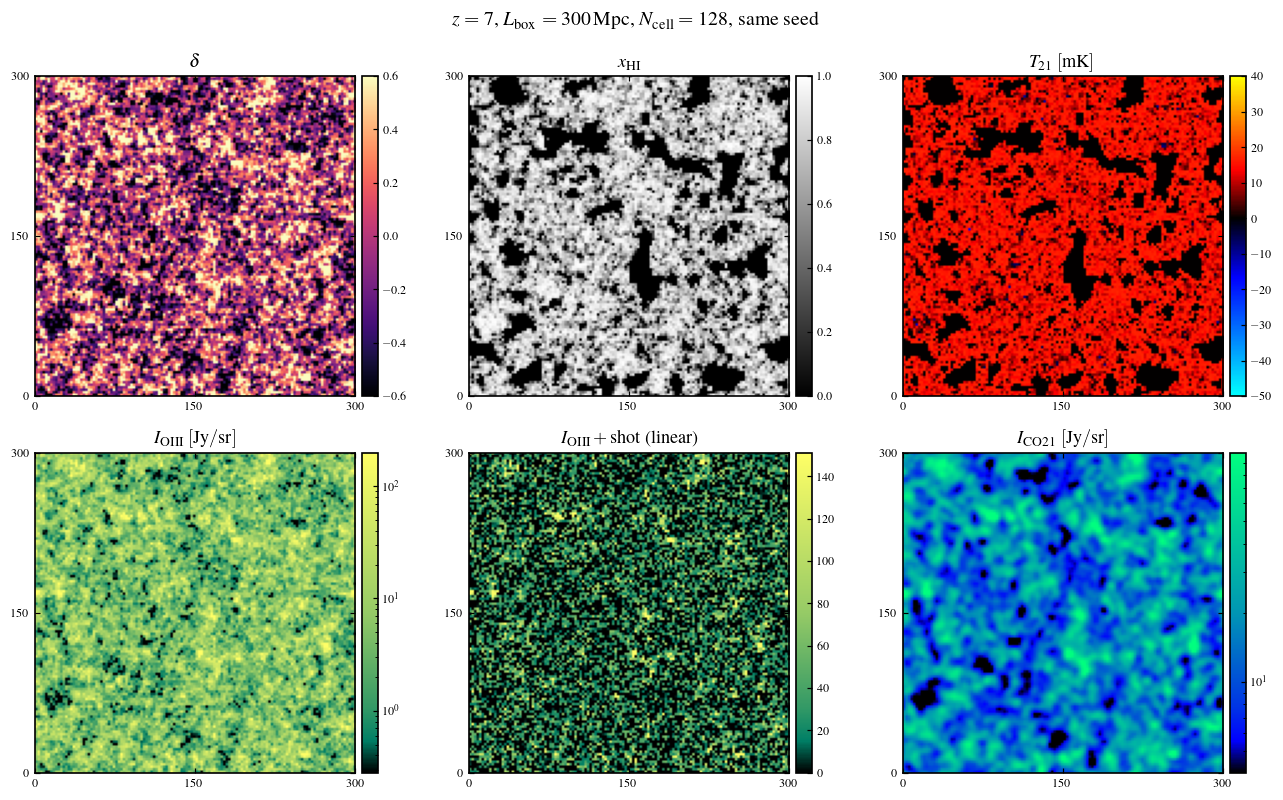

In [12]:
from matplotlib.colors import LogNorm

sl = 0
fig, axes = plt.subplots(2, 3, figsize=(12.0, 7.4))

def show(a, img, lab, cmap, scale='lin', **kw):
    if scale == 'log':
        pos = img[img > 0]
        im = a.imshow(np.ma.masked_less_equal(img, 0), origin='lower', cmap=cmap,
                      extent=[0, Lbox, 0, Lbox],
                      norm=LogNorm(vmin=np.percentile(pos, 2), vmax=np.percentile(pos, 99.5)))
    else:
        im = a.imshow(img, origin='lower', cmap=cmap, extent=[0, Lbox, 0, Lbox], **kw)
    cb = fig.colorbar(im, ax=a, fraction=0.046, pad=0.02)
    cb.ax.tick_params(labelsize=8)
    a.set_title(lab, fontsize=12)
    a.set_xticks([0, Lbox/2, Lbox]); a.set_yticks([0, Lbox/2, Lbox])
    a.tick_params(labelsize=8)

Ismooth = box_sm.Inu_box_noiseless_smooth[:, :, sl]
show(axes[0, 0], box_sm.density[:, :, sl],   r'$\delta$', 'magma', vmin=-0.6, vmax=0.6)
show(axes[0, 1], box21s.xHI[0][:, :, sl],    r'$x_{\rm HI}$', 'gray', vmin=0, vmax=1)
show(axes[0, 2], box21s.T21[0][:, :, sl],    r'$T_{21}\ [{\rm mK}]$',
     maps_LIM.eor_colour, vmin=-50, vmax=40)
show(axes[1, 0], box_sm.Inu_box_noiseless[:, :, sl],
     r'$I_{\rm OIII}\ [{\rm Jy/sr}]$', maps_LIM.LIM_colour_1, scale='log')
show(axes[1, 1], box_sm.Inu_box[:, :, sl],
     r'$I_{\rm OIII}+{\rm shot}$ (linear)', maps_LIM.LIM_colour_1,
     vmin=0, vmax=np.percentile(box_sm.Inu_box, 99))
show(axes[1, 2], box_CO.Inu_box_noiseless[:, :, sl],
     r'$I_{\rm CO21}\ [{\rm Jy/sr}]$', maps_LIM.LIM_colour_2, scale='log')

fig.suptitle(r'$z=%g$,  $L_{\rm box}=%g\,$Mpc,  $N_{\rm cell}=%d$, same seed'
             % (z_slice, Lbox, Ncell), fontsize=13)
plt.tight_layout(); plt.show()


**The shot-noise box is a Gaussian field, and that shows.** `CoevalBox_LIM_analytical`
draws the shot noise from `pbox.PowerBox` with a constant $P_{\rm shot}(k)$, i.e. white
Gaussian noise with per-cell variance $P_{\rm shot}/V_{\rm cell}$. At
$L_{\rm box}=300$ Mpc, $N_{\rm cell}=128$ that is
$\sigma_{\rm shot}\simeq43$ Jy/sr against $\bar I_\nu\simeq9$ Jy/sr at $z=7$ — so a large
fraction of cells in `Inu_box` come out **negative**. Poisson noise from a handful of sources
per cell is not Gaussian, and the two-point statistics are right while the one-point
statistics are not. The paper is explicit about this choice (Sect. VI A 2: sampling discrete
sources "would make the implementation more computationally expensive"). Practical advice:

- use `Inu_box_noiseless` for anything that depends on the PDF or on positivity;
- use `Inu_box` only when you want the correct $P_\nu+P_{\rm shot}$ in the box;
- choose $V_{\rm cell}$ large enough that $P_{\rm shot}/V_{\rm cell}\ll\bar I_\nu^2$ if you
  need both, or implement a Poisson sampler.

That is why the "+shot" panel above is on a linear scale — a log scale would mask every
negative cell.


The [OIII] and CO panels look different not only because of the line models but
because CO uses $R_0=5$ Mpc against [OIII]'s 1 Mpc — the smoothing is doing most of the
visual work. The shot-noise panel shows the small-scale Poisson grain on top of the
clustering.

**How correlated are these fields, really?** All boxes are seeded identically, so they share
the same white noise. But `CoevalBox_LIM_analytical` and `T21_maps` each apply a *different*
non-linear transform to that noise, so the correlation is high but not exact, and it is not
the analytic $r(k)$. If you need a controlled cross-correlation, either use the cell-by-cell
box (which is built from the density field directly) or work with the analytic cross-spectra
of Tutorial #1.


---
## 5. Lightcones

A lightcone stacks coeval boxes along the line of sight, with the LoS coordinate being
**comoving distance**. The construction here:

1. build coeval boxes at a set of redshifts, all with the same seed so structures line up;
2. lay out an output grid uniform in $\chi$ with the box cell size;
3. for each LoS pixel, take the transverse slice
   $i_{\rm slice}={\rm round}(\chi/{\rm d}_{\rm cell})\ \mathrm{mod}\ N_{\rm cell}$ and
   interpolate linearly in $\chi$ between the two bracketing coeval boxes.

The pattern repeats every $N_{\rm cell}$ cells along the LoS — that is intrinsic to stacking
a periodic box (21cmFAST does the same) and is the "spurious repetition" the paper warns
about. Use a box long enough that the repetition scale is outside the range you care about.


In [13]:
Llc, Nlc = 200., 64
zvals = np.linspace(5.5, 12.0, 14)          # coeval snapshots, ascending

t0 = time.time()
lim_boxes = maps_LIM.lightcone_boxes_LIM(CP, LP, coeff, pk, zvals,
                                         input_boxlength=Llc, ncells=Nlc, seed=seed,
                                         with_shot_noise=False)
print(f"{len(zvals)} LIM coeval boxes: {time.time()-t0:.1f} s")

t0 = time.time()
maps21 = T21_maps(CosmoParams=CP, CoeffStructure=T21c, PowerSpectra=T21p, input_z=zvals,
                  input_boxlength=Llc, ncells=Nlc, seed=seed, USE_xHII_MAPS=True,
                  ReioMaps_config=reio_cfg, smooth_box=False)
print(f"21-cm + xHI at {len(zvals)} redshifts: {time.time()-t0:.1f} s")

lc_lim, z_los = maps_LIM.build_lightcone(lim_boxes,  zvals, CP, Llc, Nlc)
lc_21,  _     = maps_LIM.build_lightcone(maps21.T21, zvals, CP, Llc, Nlc)
lc_xHI, _     = maps_LIM.build_lightcone(maps21.xHI, zvals, CP, Llc, Nlc)
print(f"lightcone shape {lc_lim.shape};  z from {z_los[0]:.2f} to {z_los[-1]:.2f}")
print(f"LoS pixel = {Llc/Nlc:.2f} Mpc; the box pattern repeats every "
      f"{Nlc} pixels = {Llc:.0f} Mpc")


LIM coeval boxes: 100%|██████████| 14/14 [00:02<00:00,  6.06it/s]


14 LIM coeval boxes: 2.3 s
21-cm + xHI at 14 redshifts: 4.0 s
lightcone shape (64, 64, 583);  z from 5.50 to 12.00
LoS pixel = 3.12 Mpc; the box pattern repeats every 64 pixels = 200 Mpc


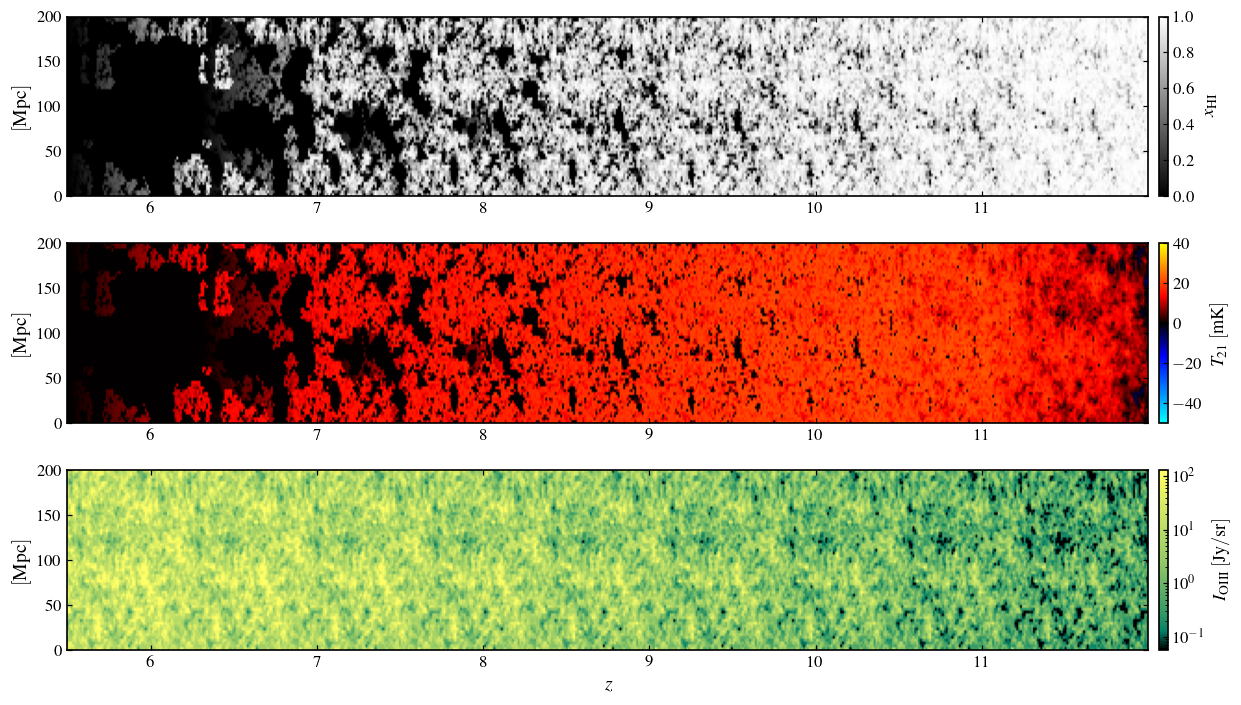

In [14]:
fig, ax = plt.subplots(3, 1, figsize=(11.5, 6.6))
maps_LIM.plot_lightcone(lc_xHI, z_los, Llc, label=r'$x_{\rm HI}$', cmap='gray',
                        vmin=0, vmax=1, ax=ax[0], fig=fig)
maps_LIM.plot_lightcone(lc_21, z_los, Llc, label=r'$T_{21}\ [{\rm mK}]$',
                        cmap=maps_LIM.eor_colour, vmin=-50, vmax=40, ax=ax[1], fig=fig)
maps_LIM.plot_lightcone(lc_lim, z_los, Llc, label=r'$I_{\rm OIII}\ [{\rm Jy/sr}]$',
                        cmap=maps_LIM.LIM_colour_1, log=True, ax=ax[2], fig=fig)
for a in ax[:2]:
    a.set_xlabel('')
plt.tight_layout(); plt.show()


Reading the figure: ionized bubbles grow and merge toward low $z$; $T_{21}$ is
extinguished where $x_{\rm HI}\to0$; the [OIII] intensity rises monotonically as the SFRD
grows. The [OIII] and $T_{21}$ panels are visibly *anti*-correlated at $z\lesssim7$ — that
is the effect Tutorial #4 quantifies with the Pearson coefficient
([arXiv:2509.08886](https://arxiv.org/abs/2509.08886)).

### Checks on the lightcone


In [15]:
print(f"{'z':>6s} {'<I>_lc':>10s} {'Inu_bar':>10s} {'<T21>_lc':>10s} {'T21avg':>10s} "
      f"{'<xHI>_lc':>10s} {'xHI_avg':>10s}")
for zz in (6., 7., 8., 10.):
    j = np.argmin(abs(z_los - zz))
    print(f"{z_los[j]:6.2f} {lc_lim[:,:,j].mean():10.3f} "
          f"{np.interp(z_los[j], coeff.zintegral, coeff.Inu_bar):10.3f} "
          f"{lc_21[:,:,j].mean():10.3f} "
          f"{np.interp(z_los[j], T21c.zintegral, T21c.T21avg):10.3f} "
          f"{lc_xHI[:,:,j].mean():10.3f} "
          f"{np.interp(z_los[j], T21c.zintegral, T21c.xHI_avg):10.3f}")
print("\nRead this table carefully:")
print(" * <I>_lc vs Inu_bar: agree to a few per cent -- the residual is the sample")
print("   variance of a single L=200 Mpc transverse plane, not a bias.")
print(" * <xHI>_lc vs xHI_avg: agree at z >= 8, where the box is still mostly neutral;")
print("   the relative offset grows as xHI shrinks (0.22 vs 0.03 at z=6). In terms of")
print("   xHII the same offset is only ~20%. See the warning in Sect. 3.")
print(" * <T21>_lc inherits that error, because T21_box = T21_noXH * xHI_box. It")
print("   tracks T21avg at z >= 8 and is ~6x too large at z = 6.")


     z     <I>_lc    Inu_bar   <T21>_lc     T21avg   <xHI>_lc    xHI_avg
  6.00     19.909     23.715      3.837      0.661      0.217      0.030
  7.00     12.823     13.693     11.267      9.365      0.563      0.398
  8.00      8.210      7.791     14.490     15.359      0.654      0.632
 10.01      2.213      2.418     18.693     19.172      0.877      0.867

Read this table carefully:
 * <I>_lc vs Inu_bar: agree to a few per cent -- the residual is the sample
   variance of a single L=200 Mpc transverse plane, not a bias.
 * <xHI>_lc vs xHI_avg: agree at z >= 8, where the box is still mostly neutral;
   the relative offset grows as xHI shrinks (0.22 vs 0.03 at z=6). In terms of
   xHII the same offset is only ~20%. See the warning in Sect. 3.
 * <T21>_lc inherits that error, because T21_box = T21_noXH * xHI_box. It
   tracks T21avg at z >= 8 and is ~6x too large at z = 6.


---
## 6. Cost summary and practical advice

| box | $N_{\rm cell}=64$ | $N_{\rm cell}=128$ | scaling | memory |
|---|---|---|---|---|
| `CoevalBox_LIM_analytical` | $\lesssim0.1$ s | $\sim1$ s | $N^3\log N$ | modest |
| `T21_maps` (+ reionization) | $\sim0.5$ s | $\sim5$ s | $N^3\times N_R$ | modest |
| `CoevalBox_percell` | $\sim2$ s | $\sim20$ s | $N_M\times N^3$ | **$\sim(N/100)^3\times2$ GB** |

Rules of thumb:

- Keep $N_{\rm cell}\lesssim L_{\rm box}/2$ so the box Nyquist stays inside the tabulated
  $P_\nu$ range.
- Use the **same seed** across all fields you intend to cross-correlate.
- Use `CoevalBox_percell` only for validation, and only when
  $L_{\rm box}/N_{\rm cell}\le R_0$; otherwise the smoothing scale is set by the cell size,
  not by $R_0$, and you are not comparing like with like.
- If `CoevalBox_percell` runs out of memory, the fix is to chunk the cell axis — the
  $(N_M, N_{\rm cell}^3)$ broadcast is the only reason it is expensive.

### Next
- **#3** — exploring the parameter space
- **#4** — 21-cm $\times$ line cross-correlation during the EoR
